In [1]:
import numpy as np  #Handling maths
import pandas as pd  #Data Handling
import matplotlib.pyplot as plt  #Visualization

In [2]:
df=pd.read_csv('1_boston_housing.csv')
df.head()

# It has 13 input features (like crime rate, number of rooms, tax rate, etc.) and one target column MEDV — the median house price in $1000s.

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
df.isna().sum()

# df.isna()
# This checks every cell and returns:
# True → if value is missing (NaN/None)
# False → if value exists

# .sum() counts the number of True values column-wise.

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [4]:
from sklearn.model_selection import train_test_split
# Split features and target
X = df.drop('MEDV', axis=1)
y = df['MEDV']
print(X.shape, y.shape)


(506, 13) (506,)


In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Splits the data: 80% for training, 20% for testing. random_state=42 ensures reproducibility.

In [6]:
from sklearn.preprocessing import StandardScaler
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Neural networks are sensitive to the scale of inputs. StandardScaler converts each feature to have mean = 0 and standard deviation = 1.

In [7]:
!pip install tensorflow
import tensorflow as tf
print(tf.__version__)

2.21.0


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Build Neural Network
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(13,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))   # regression output

# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display a summary of the model architecture
model.summary()

C:\Users\praja\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Train model
model.fit(X_train, y_train, epochs=50, verbose=1)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 628.3088 - mae: 23.2050
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 583.3458 - mae: 22.2470 
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 538.2004 - mae: 21.2634
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 488.4252 - mae: 20.0884 
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 426.2472 - mae: 18.5422 
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 349.2406 - mae: 16.4909 
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 262.3907 - mae: 13.9570 
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 183.1978 - mae: 11.1345 
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 119.1168 - mae: 8.6550
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 83.4012 - mae: 7.1171  
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 61.7927 - mae: 6.0924 
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 48.2855 - mae: 5.3053
Epoch 13/5

In [31]:

loss, mae = model.evaluate(X_test, y_test)
rmse = np.sqrt(loss)
print("MSE:", loss)
print("MAE:", mae)
print("RMSE:", rmse)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 15.2579 - mae: 2.5994
MSE: 15.257903099060059
MAE: 2.599400043487549
RMSE: 3.90613659503352


In [35]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
R² Score: 0.7919389477109894


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step


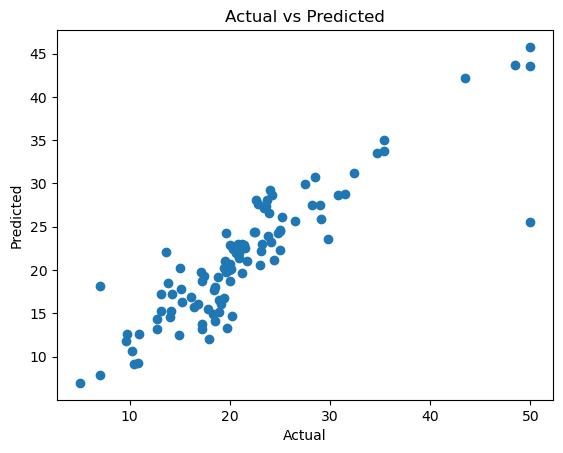

In [33]:
# Predictions
y_pred = model.predict(X_test)
# Scatter Plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [39]:
print("Predicted House Prices:")
print(y_pred[:5])

Predicted House Prices:
[[27.423826]
 [31.230202]
 [22.115814]
 [27.662462]
 [16.910551]]


In [45]:
from tensorflow.keras.datasets import boston_housing
(X_train, y_train), (X_test, y_test) =boston_housing.load_data()



57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step


In [47]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
